<a href="https://colab.research.google.com/github/kyungeunvoyage/NailFoldExp/blob/Ipynb/DataAnalysis_2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [27]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# 그래프 스타일 설정
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (15, 6)

In [28]:
# 파일 리스트 (본인의 파일명에 맞게 수정)
file_names = ['Tactile_S01.csv','Tactile_S02.csv','Tactile_S03.csv','Tactile_S04.csv']
data_list = []

for file in file_names:
    try:
        temp_df = pd.read_csv(file)
        data_list.append(temp_df)
    except FileNotFoundError:
        print(f"no: {file}")

# 데이터 통합
if data_list:
    df = pd.concat(data_list, ignore_index=True)

    # 1. Condition 명칭 변경 (Active -> On-touch)
    df['Condition'] = df['Condition'].replace('Active', 'On-touch')

    # 2. 분석 대상 구역 필터링 (Area A, B, C)
    df = df[df['Area'].isin(['A', 'B', 'C'])]

    # 3. Force 문자열에서 숫자만 추출 (예: '0.07g' -> 0.07)
    df['Force_Val'] = df['Force'].str.extract('(\d+\.?\d*)').astype(float)

    print("완")
else:
    print("없")

완


<>:23: SyntaxWarning: invalid escape sequence '\d'
<>:23: SyntaxWarning: invalid escape sequence '\d'
/tmp/ipykernel_182/2368123284.py:23: SyntaxWarning: invalid escape sequence '\d'
  df['Force_Val'] = df['Force'].str.extract('(\d+\.?\d*)').astype(float)


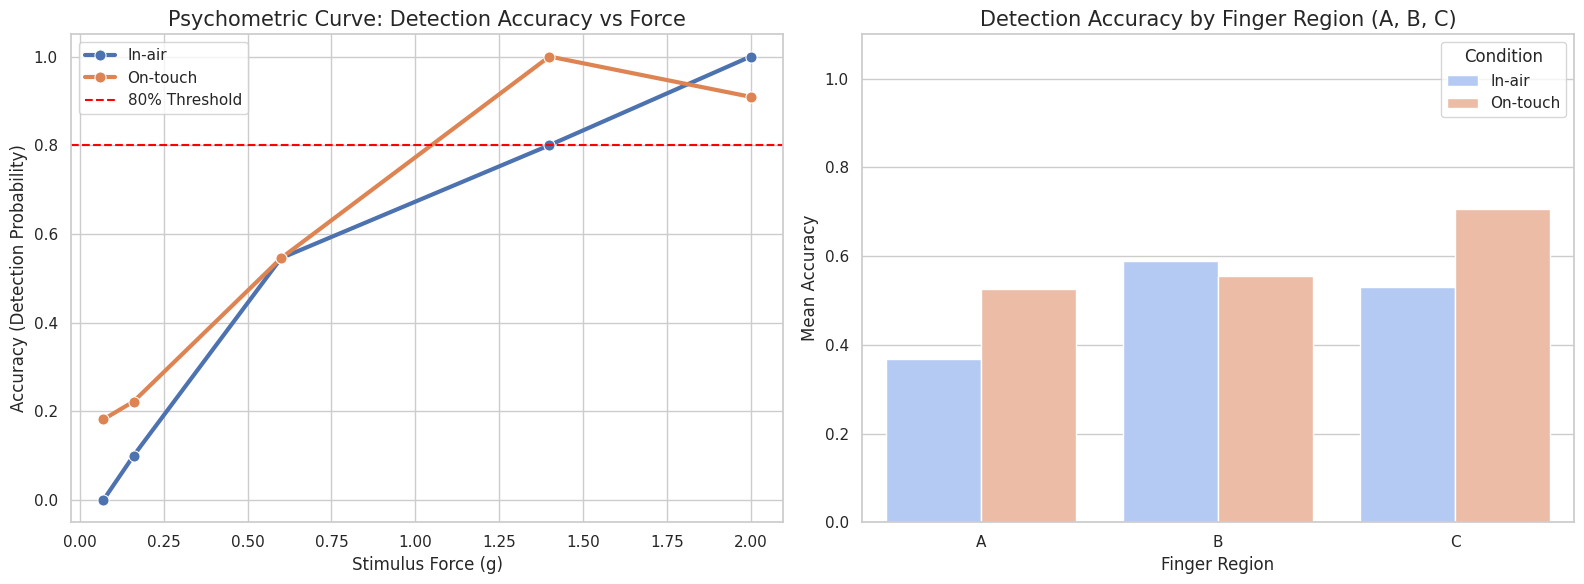

In [29]:
# 1. 전반적인 강도별 정답률 계산 (Psychometric Curve용)
overall_acc = df.groupby(['Condition', 'Force_Val'])['IsCorrect'].mean().reset_index()

# 2. 구역별(Area) 평균 정답률 계산 (Bar Chart용)
area_acc = df.groupby(['Condition', 'Area'])['IsCorrect'].mean().reset_index()

# 그래프 그리기
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# (Left) Psychometric Curve
sns.lineplot(ax=axes[0], data=overall_acc, x='Force_Val', y='IsCorrect',
             hue='Condition', marker='o', linewidth=3, markersize=8)
axes[0].axhline(0.8, color='red', linestyle='--', label='80% Threshold')
axes[0].set_title('Psychometric Curve: Detection Accuracy vs Force', fontsize=15)
axes[0].set_xlabel('Stimulus Force (g)', fontsize=12)
axes[0].set_ylabel('Accuracy (Detection Probability)', fontsize=12)
axes[0].set_ylim(-0.05, 1.05)
axes[0].legend()

# (Right) Regional Accuracy
sns.barplot(ax=axes[1], data=area_acc, x='Area', y='IsCorrect',
            hue='Condition', order=['A', 'B', 'C'], palette='coolwarm')
axes[1].set_title('Detection Accuracy by Finger Region (A, B, C)', fontsize=15)
axes[1].set_xlabel('Finger Region', fontsize=12)
axes[1].set_ylabel('Mean Accuracy', fontsize=12)
axes[1].set_ylim(0, 1.1)

plt.tight_layout()
plt.show()

In [30]:
print("="*40)
print("       [SUMMARY STATISTICS]       ")
print("="*40)

# 역치 산출 (정답률 80% 기준 최소 강도)
print("\n1. Estimated Absolute Thresholds (80% Accuracy):")
for cond in overall_acc['Condition'].unique():
    cond_df = overall_acc[overall_acc['Condition'] == cond]
    threshold_df = cond_df[cond_df['IsCorrect'] >= 0.8]

    if not threshold_df.empty:
        threshold = threshold_df['Force_Val'].min()
        print(f" - {cond}: {threshold}g")
    else:
        print(f" - {cond}: 80% 정답률에 도달하지 못함")

# 구역별 상세 정답률 출력
print("\n2. Regional Accuracy Table:")
pivot_area = area_acc.pivot(index='Area', columns='Condition', values='IsCorrect')
print(pivot_area)

# 강도별 상세 정답률 출력
print("\n3. Force-wise Accuracy Table:")
pivot_force = overall_acc.pivot(index='Force_Val', columns='Condition', values='IsCorrect')
print(pivot_force)

       [SUMMARY STATISTICS]       

1. Estimated Absolute Thresholds (80% Accuracy):
 - In-air: 1.4g
 - On-touch: 1.4g

2. Regional Accuracy Table:
Condition    In-air  On-touch
Area                         
A          0.368421  0.526316
B          0.588235  0.555556
C          0.529412  0.705882

3. Force-wise Accuracy Table:
Condition    In-air  On-touch
Force_Val                    
0.07       0.000000  0.181818
0.16       0.100000  0.222222
0.60       0.545455  0.545455
1.40       0.800000  1.000000
2.00       1.000000  0.909091


##relative accuracy || error based score

In [31]:
for file in file_names:
    try:
        temp_df = pd.read_csv(file)
        data_list.append(temp_df)
    except FileNotFoundError:
        print(f"no: {file}")

# 데이터 통합
if data_list:
    df = pd.concat(data_list, ignore_index=True)

    # 1. Condition 명칭 변경 (Active -> On-touch)
    df['Condition'] = df['Condition'].replace('Active', 'On-touch')

    # 2. 분석 대상 구역 필터링 (Area A, B, C)
    #df = df[df['Area'].isin(['A', 'B', 'C'])]

    # 3. Force 문자열에서 숫자만 추출 (예: '0.07g' -> 0.07)
    df['Force_Val'] = df['Force'].str.extract('(\d+\.?\d*)').astype(float)

    print("완")
else:
    print("없")

완


<>:19: SyntaxWarning: invalid escape sequence '\d'
<>:19: SyntaxWarning: invalid escape sequence '\d'
/tmp/ipykernel_182/1978903883.py:19: SyntaxWarning: invalid escape sequence '\d'
  df['Force_Val'] = df['Force'].str.extract('(\d+\.?\d*)').astype(float)


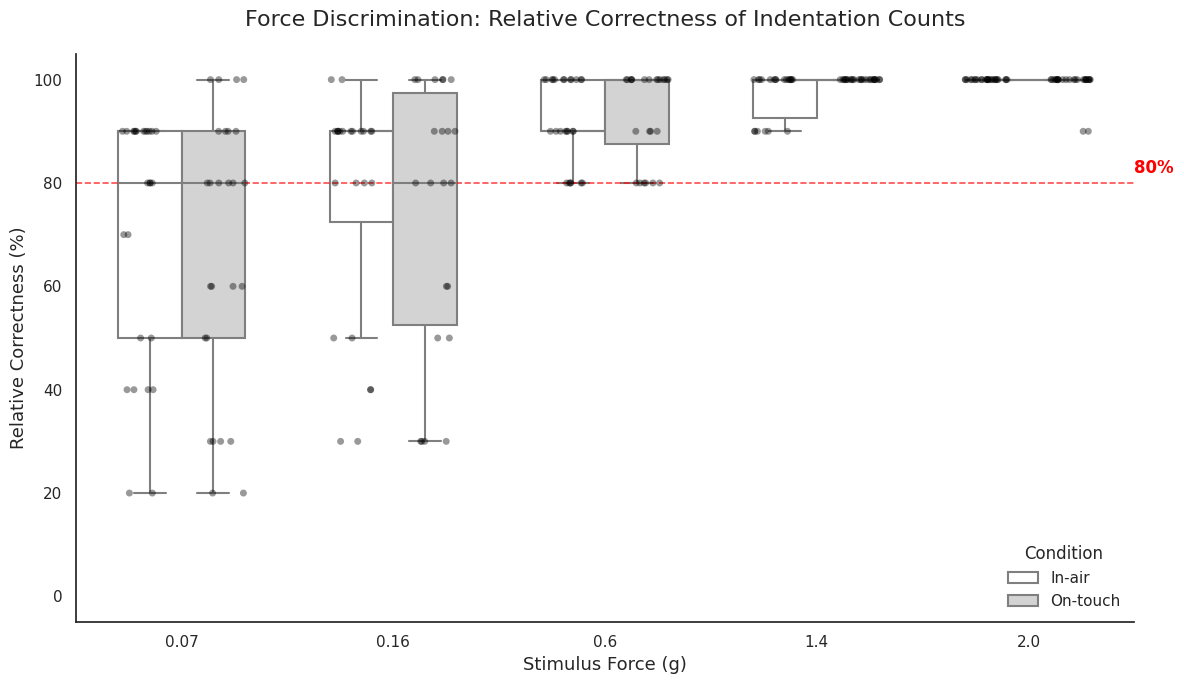

In [32]:
# 2. Relative Score 계산 (사용자 기준: 오차 1회당 10% 감점)
def calc_relative_score(row):
    error = abs(row['Target'] - row['Response'])
    # 100점에서 오차 1회당 10점씩 감점 (최소 0점)
    score = 100 - (error * 10)
    return max(0, score)

df['Relative_Score'] = df.apply(calc_relative_score, axis=1)

# 3. 시각화 (Box plot + Scatter point)
plt.figure(figsize=(12, 7))
sns.set_theme(style="white")

# X축 순서 (Force 강도 순)
force_order = sorted(df['Force_Val'].unique())

# Box plot (이미지 스타일: 투명/회색 박스)
ax = sns.boxplot(
    data=df, x='Force_Val', y='Relative_Score', hue='Condition',
    palette=['#FFFFFF', '#D3D3D3'], # In-air: White, On-touch: Light Grey
    linewidth=1.5, fliersize=0, width=0.6, order=force_order,
    medianprops={'color': 'red', 'linewidth': 2}  # 빨간색 중앙값 선 설정
)

# Scatter point (Strip plot) 겹치기
sns.stripplot(
    data=df, x='Force_Val', y='Relative_Score', hue='Condition',
    dodge=True, palette=['#000000', '#000000'], # 검은색 점
    alpha=0.4, size=5, jitter=0.2, ax=ax, order=force_order
)

# 80% 가이드라인 추가
plt.axhline(80, color='red', linestyle='--', linewidth=1.2, alpha=0.7)
plt.text(len(force_order)-0.5, 82, '80%', color='red', fontsize=12, fontweight='bold')

# 서식 및 라벨 설정
plt.title('Force Discrimination: Relative Correctness of Indentation Counts', fontsize=16, pad=20)
plt.xlabel('Stimulus Force (g)', fontsize=13)
plt.ylabel('Relative Correctness (%)', fontsize=13)
plt.ylim(-5, 105)

# 레전드 정리
handles, labels = ax.get_legend_handles_labels()
plt.legend(handles[0:2], labels[0:2], title='Condition', frameon=False, loc='lower right')

sns.despine() # 테두리 정리
plt.tight_layout()
plt.show()

##Region별 accuracy

In [33]:
# 1. 파일 리스트 (본인의 CSV 파일명으로 수정)
file_names = ['Tactile_S01.csv','Tactile_S02.csv','Tactile_S03.csv', 'Tactile_S04.csv']
df_list = []

for f in file_names:
    try:
        temp = pd.read_csv(f)
        df_list.append(temp)
    except FileNotFoundError:
        print(f"⚠️ 파일을 찾을 수 없음: {f}")

# 2. 데이터 통합 및 클리닝
df = pd.concat(df_list, ignore_index=True)
df['Condition'] = df['Condition'].replace('Active', 'On-touch')
df = df[df['Area'].isin(['A', 'B', 'C'])]
# '0.07g' 문자열에서 숫자만 추출
df['Force_Val'] = df['Force'].str.extract('(\d+\.?\d*)').astype(float)

# 3. 구역별/강도별 정답률 계산 (Dilution 방지 핵심)
region_acc = df.groupby(['Condition', 'Area', 'Force_Val'])['IsCorrect'].mean().reset_index()

print("✅ 데이터 전처리 및 Region별 그룹화 완료")

✅ 데이터 전처리 및 Region별 그룹화 완료


<>:17: SyntaxWarning: invalid escape sequence '\d'
<>:17: SyntaxWarning: invalid escape sequence '\d'
/tmp/ipykernel_182/3903644341.py:17: SyntaxWarning: invalid escape sequence '\d'
  df['Force_Val'] = df['Force'].str.extract('(\d+\.?\d*)').astype(float)


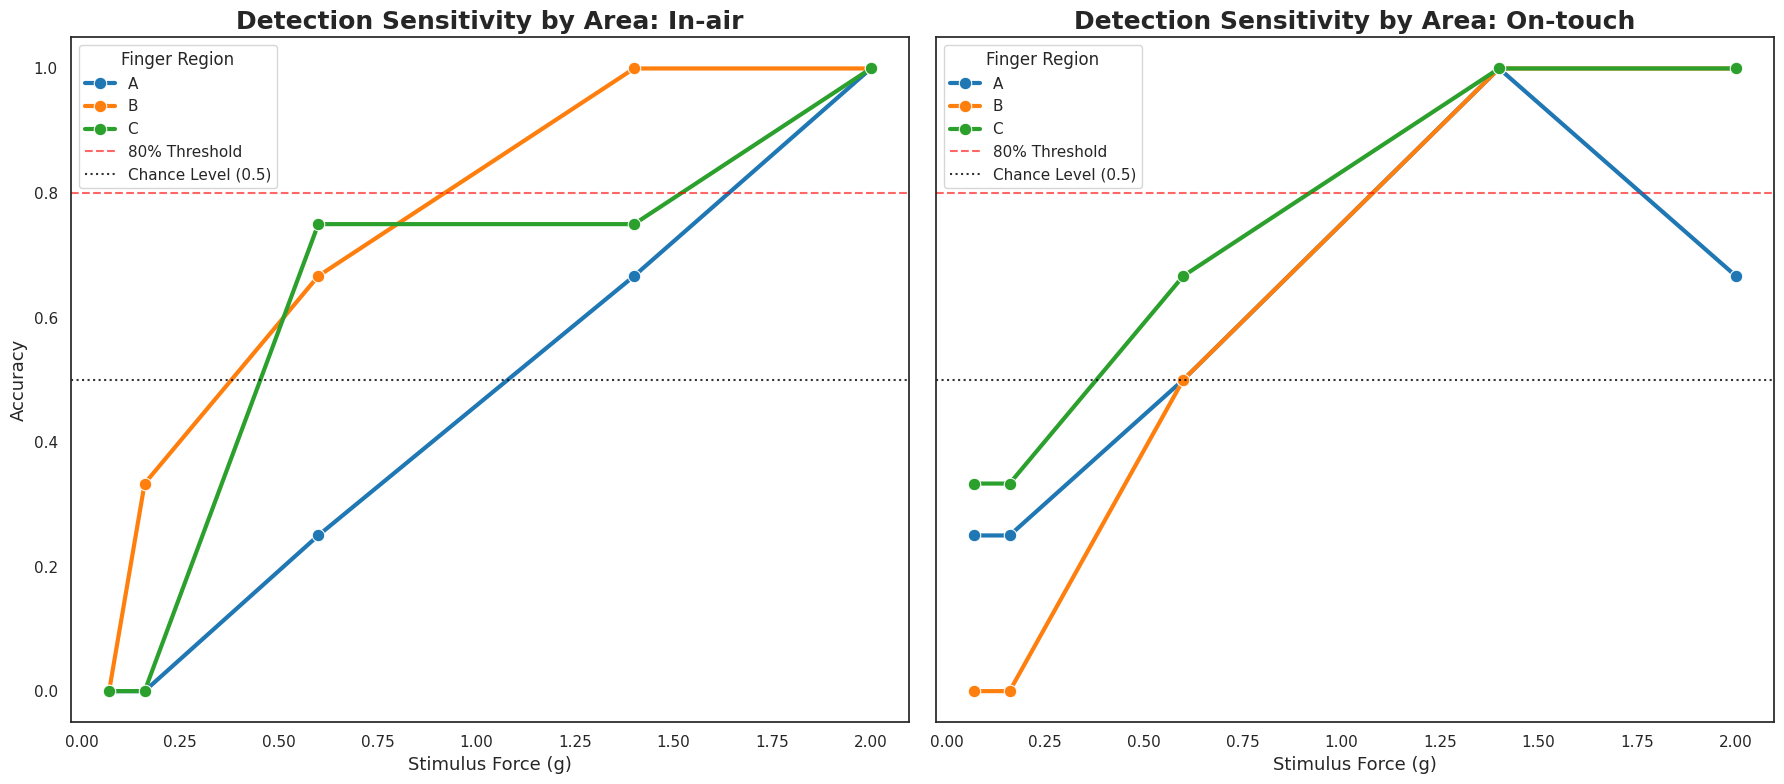

In [34]:
# In-air와 On-touch를 비교하기 위한 1x2 서브플롯
fig, axes = plt.subplots(1, 2, figsize=(18, 8), sharey=True)

conditions = ['In-air', 'On-touch']
# 구역별 색상 고정 (A: 청색, B: 황색, C: 녹색)
colors = {"A": "#1f77b4", "B": "#ff7f0e", "C": "#2ca02c"}

for i, cond in enumerate(conditions):
    cond_data = region_acc[region_acc['Condition'] == cond]

    # Area별로 선을 따로 그림
    sns.lineplot(
        ax=axes[i],
        data=cond_data,
        x='Force_Val',
        y='IsCorrect',
        hue='Area',
        hue_order=['A', 'B', 'C'],
        palette=colors,
        marker='o',
        linewidth=3,
        markersize=9
    )

    # 기준선 추가 (80% 역치 및 50% 찍기 수준)
    axes[i].axhline(0.8, color='red', linestyle='--', alpha=0.6, label='80% Threshold')
    axes[i].axhline(0.5, color='black', linestyle=':', alpha=0.8, label='Chance Level (0.5)')

    axes[i].set_title(f'Detection Sensitivity by Area: {cond}', fontsize=18, fontweight='bold')
    axes[i].set_xlabel('Stimulus Force (g)', fontsize=13)
    axes[i].set_ylabel('Accuracy', fontsize=13)
    axes[i].set_ylim(-0.05, 1.05)
    axes[i].legend(title="Finger Region", fontsize=11)

plt.tight_layout()
plt.show()

In [35]:
print("="*50)
print(" [각 조건/구역별 80% 정답률 도달 Force (g)] ")
print("="*50)

# 정답률이 0.8 이상인 데이터 중 가장 작은 Force 값을 찾음
thresholds = region_acc[region_acc['IsCorrect'] >= 0.8].groupby(['Condition', 'Area'])['Force_Val'].min().reset_index()

# 보기 좋게 피벗 테이블로 출력
pivot_thresholds = thresholds.pivot(index='Area', columns='Condition', values='Force_Val')
print(pivot_thresholds)

print("\n💡 해석 팁: 값이 작을수록 더 낮은 힘에서 자극을 감지했다는 뜻임.")

 [각 조건/구역별 80% 정답률 도달 Force (g)] 
Condition  In-air  On-touch
Area                       
A             2.0       1.4
B             1.4       1.4
C             2.0       1.4

💡 해석 팁: 값이 작을수록 더 낮은 힘에서 자극을 감지했다는 뜻임.


In [36]:
# 각 조건/구역별로 정확히 80%를 넘는 최소 Force 값을 찾는 코드
thresholds = region_acc[region_acc['IsCorrect'] >= 0.8].groupby(['Condition', 'Area'])['Force_Val'].min()
print(thresholds)

Condition  Area
In-air     A       2.0
           B       1.4
           C       2.0
On-touch   A       1.4
           B       1.4
           C       1.4
Name: Force_Val, dtype: float64
